In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

import seaborn as sns

from collections import Counter

import os

In [ ]:
DATA_PATH = "/content/drive/MyDrive/FIFI_Research/data"

train_path = os.path.join(DATA_PATH, "train.tsv")
val_path = os.path.join(DATA_PATH, "val.tsv")
meta_titles_path = os.path.join(DATA_PATH, "meta_train_titles.tsv")
meta_path = os.path.join(DATA_PATH, "Meta_train.csv")

In [ ]:
train_df = pd.read_csv(train_path, sep="\t")

val_df = pd.read_csv(val_path, sep="\t")

meta_titles = pd.read_csv(meta_titles_path, sep="\t")

meta_df = pd.read_csv(meta_path)

In [ ]:
train_df.head()

,id,category,generated_title,original_title
0,0,technical,Optimizing Class-Specific Complex Network Gene...,Improve High Level Classification with a More ...
1,1,technical,Monte Carlo Self-Supervised Proposal-Based Obj...,Self-supervised Training of Proposal-based Seg...
2,2,technical,Task-Level Planning and Simulation for Robotic...,Towards Spiral Brick Column Building Robots
3,3,accessible,Using Map Search Data to Find the Best Locatio...,Store Location Selection via Mining Search Que...
4,4,technical,Evaluating the Perceptual Capabilities and Cog...,Potentials and Limitations of Deep Neural Netw...


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               90000 non-null  int64 
 1   category         90000 non-null  object
 2   generated_title  90000 non-null  object
 3   original_title   90000 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.7+ MB


In [ ]:
train_df.describe(include="all")

,id,category,generated_title,original_title
count,90000.000000,90000,90000,90000
unique,NaN,3,89936,9999
top,NaN,technical,Second-Order Convergence Guarantees for Stocha...,Distributed Online Learning with Multiple Kernels
freq,NaN,30000,3,18
mean,44999.500000,NaN,NaN,NaN
std,25980.906451,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN
25%,22499.750000,NaN,NaN,NaN
50%,44999.500000,NaN,NaN,NaN
75%,67499.250000,NaN,NaN,NaN


In [ ]:
print("Training Samples :", len(train_df))
print("Validation Samples :", len(val_df))

print("Unique Original Titles :", train_df["original_title"].nunique())

print("Unique Generated Titles :", train_df["generated_title"].nunique())

Training Samples : 90000
Validation Samples : 18000
Unique Original Titles : 9999
Unique Generated Titles : 89936


In [ ]:
train_df["category"].value_counts()

,count
category,
technical,30000
accessible,30000
catchy,30000


In [ ]:
train_df.isnull().sum()

,0
id,0
category,0
generated_title,0
original_title,0


In [ ]:
train_df.duplicated().sum()

np.int64(0)

In [ ]:
train_df["original_title"].duplicated().sum()

np.int64(80001)

In [ ]:
train_df["generated_title"].duplicated().sum()

np.int64(64)

In [ ]:
train_df["generated_words"] = train_df["generated_title"].str.split().str.len()

train_df["original_words"] = train_df["original_title"].str.split().str.len()

In [ ]:
train_df[["generated_words","original_words"]].describe()

,generated_words,original_words
count,90000.000000,90000.00000
mean,12.572444,9.17120
std,2.436486,3.18129
min,4.000000,1.00000
25%,11.000000,7.00000
50%,12.000000,9.00000
75%,14.000000,11.00000
max,29.000000,29.00000


In [ ]:
train_df["generated_chars"] = train_df["generated_title"].str.len()

train_df["original_chars"] = train_df["original_title"].str.len()

In [ ]:
train_df[["generated_chars","original_chars"]].describe()

,generated_chars,original_chars
count,90000.000000,90000.000000
mean,93.102956,73.572800
std,21.867865,23.939204
min,29.000000,6.000000
25%,78.000000,57.000000
50%,89.000000,71.000000
75%,105.000000,88.000000
max,234.000000,231.000000


In [ ]:
all_words = " ".join(train_df["generated_title"]).lower().split()

Counter(all_words).most_common(30)

[('and', 32722),
 ('for', 32206),
 ('to', 29191),
 ('a', 23938),
 ('the', 20940),
 ('in', 20256),
 ('learning', 15783),
 ('how', 14012),
 ('of', 13995),
 ('with', 13771),
 ('neural', 8978),
 ('using', 8928),
 ('from', 8811),
 ('networks', 8411),
 ('ai', 8236),
 ('teaching', 7476),
 ('via', 7146),
 ('data', 6995),
 ('deep', 6667),
 ('when', 6025),
 ('models', 5187),
 ('by', 5166),
 ('on', 4150),
 ('image', 4129),
 ('better', 4111),
 ('network', 4052),
 ('can', 3743),
 ('detection', 3389),
 ('training', 3377),
 ('that', 3260)]

In [ ]:
all_words = " ".join(train_df["original_title"]).lower().split()

Counter(all_words).most_common(30)

[('for', 35586),
 ('of', 20322),
 ('and', 19845),
 ('learning', 18171),
 ('a', 16587),
 ('in', 14337),
 ('with', 13320),
 ('the', 10179),
 ('neural', 9216),
 ('deep', 9153),
 ('using', 8469),
 ('on', 7182),
 ('networks', 7146),
 ('to', 6831),
 ('network', 5373),
 ('from', 4986),
 ('detection', 4977),
 ('image', 4176),
 ('via', 4167),
 ('data', 4149),
 ('models', 3537),
 ('an', 3339),
 ('based', 3303),
 ('model', 3276),
 ('classification', 3267),
 ('machine', 3087),
 ('recognition', 2790),
 ('segmentation', 2745),
 ('adversarial', 2709),
 ('analysis', 2538)]

In [ ]:
plt.savefig(
    "/content/drive/MyDrive/FIFI_Research/figures/category_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

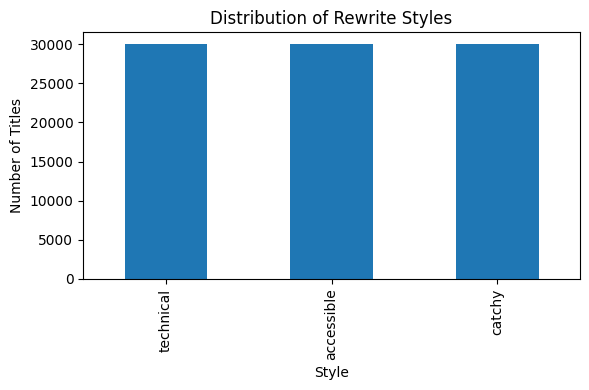

In [ ]:
import matplotlib.pyplot as plt

counts = train_df["category"].value_counts()

plt.figure(figsize=(6,4))

counts.plot(kind="bar")

plt.title("Distribution of Rewrite Styles")

plt.xlabel("Style")

plt.ylabel("Number of Titles")

plt.tight_layout()

plt.savefig("/content/drive/MyDrive/FIFI_Research/figures/category_distribution.png", dpi=300)

plt.show()

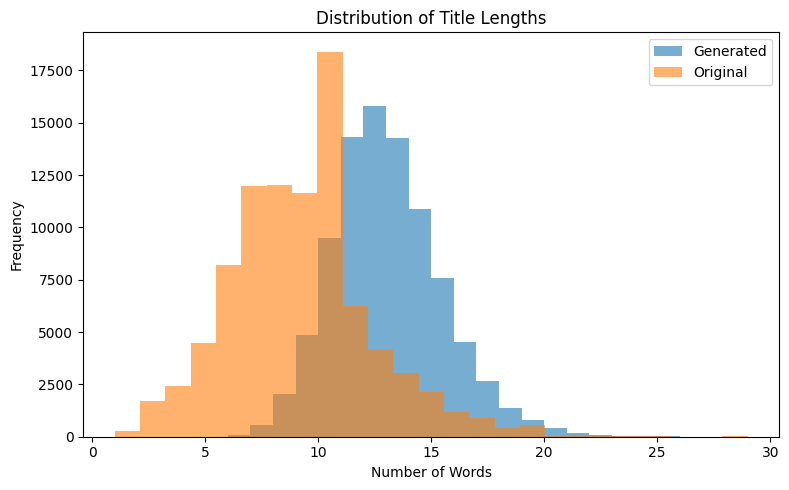

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(train_df["generated_words"],
         bins=25,
         alpha=0.6,
         label="Generated")

plt.hist(train_df["original_words"],
         bins=25,
         alpha=0.6,
         label="Original")

plt.legend()

plt.xlabel("Number of Words")

plt.ylabel("Frequency")

plt.title("Distribution of Title Lengths")

plt.tight_layout()

plt.savefig("/content/drive/MyDrive/FIFI_Research/figures/word_length_distribution.png", dpi=300)

plt.show()

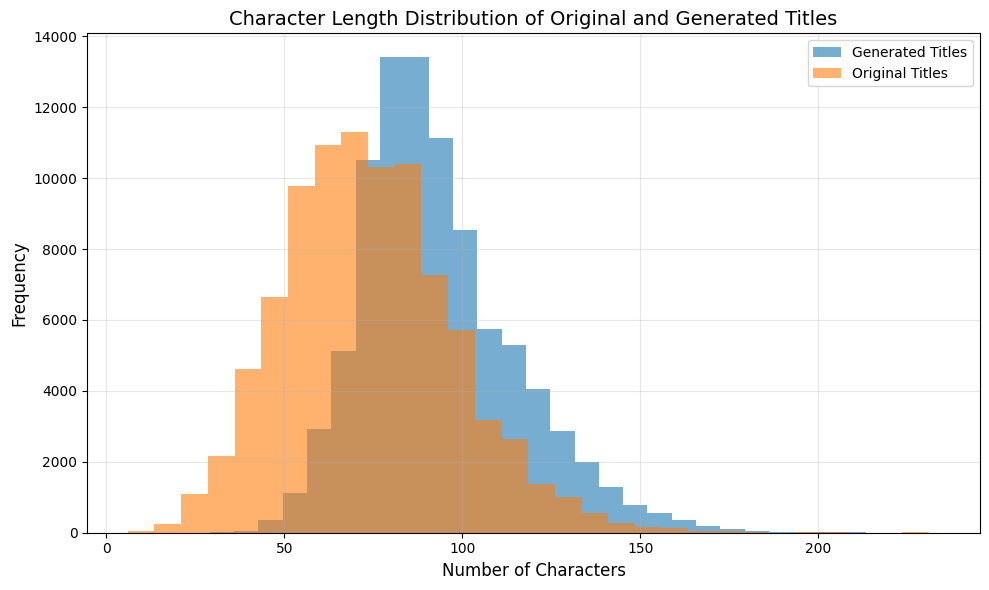

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(train_df["generated_chars"],
         bins=30,
         alpha=0.6,
         label="Generated Titles")

plt.hist(train_df["original_chars"],
         bins=30,
         alpha=0.6,
         label="Original Titles")

plt.xlabel("Number of Characters", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Character Length Distribution of Original and Generated Titles",
          fontsize=14)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("/content/drive/MyDrive/FIFI_Research/figures/Figure3_character_distribution.png",
            dpi=300)

plt.show()

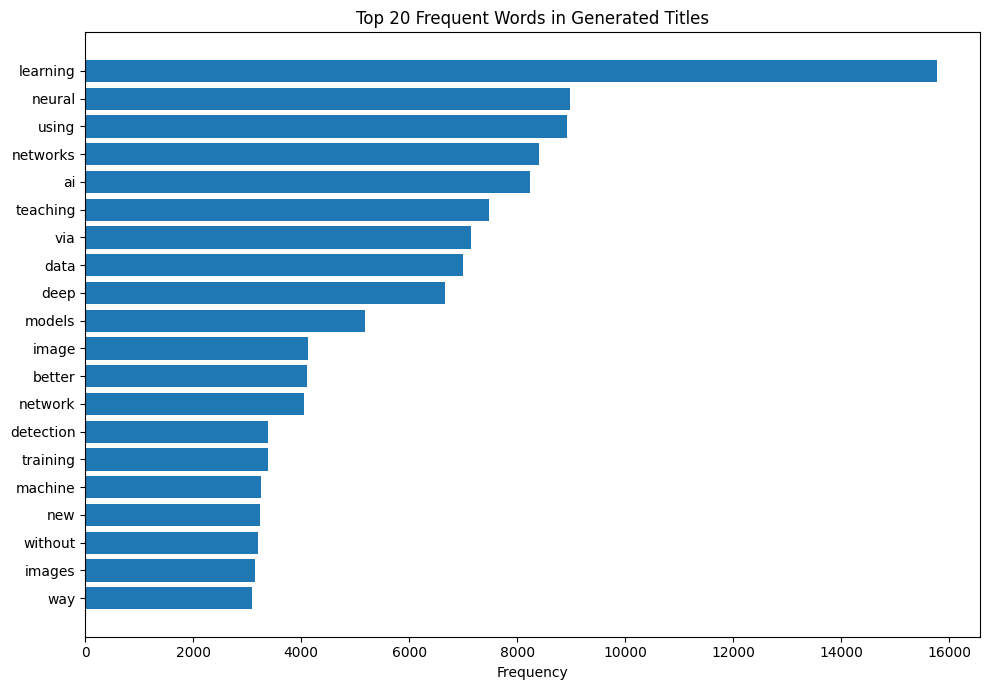

In [ ]:
from collections import Counter
from wordcloud import STOPWORDS

stop_words = set(STOPWORDS)

generated_words = []

for title in train_df["generated_title"]:
    words = title.lower().split()

    generated_words.extend([w for w in words if w not in stop_words])

top20 = Counter(generated_words).most_common(20)

words = [x[0] for x in top20]
counts = [x[1] for x in top20]

plt.figure(figsize=(10,7))

plt.barh(words[::-1], counts[::-1])

plt.xlabel("Frequency")
plt.title("Top 20 Frequent Words in Generated Titles")

plt.tight_layout()

plt.savefig("/content/drive/MyDrive/FIFI_Research/figures/Figure4_top20_generated_words.png",
            dpi=300)

plt.show()

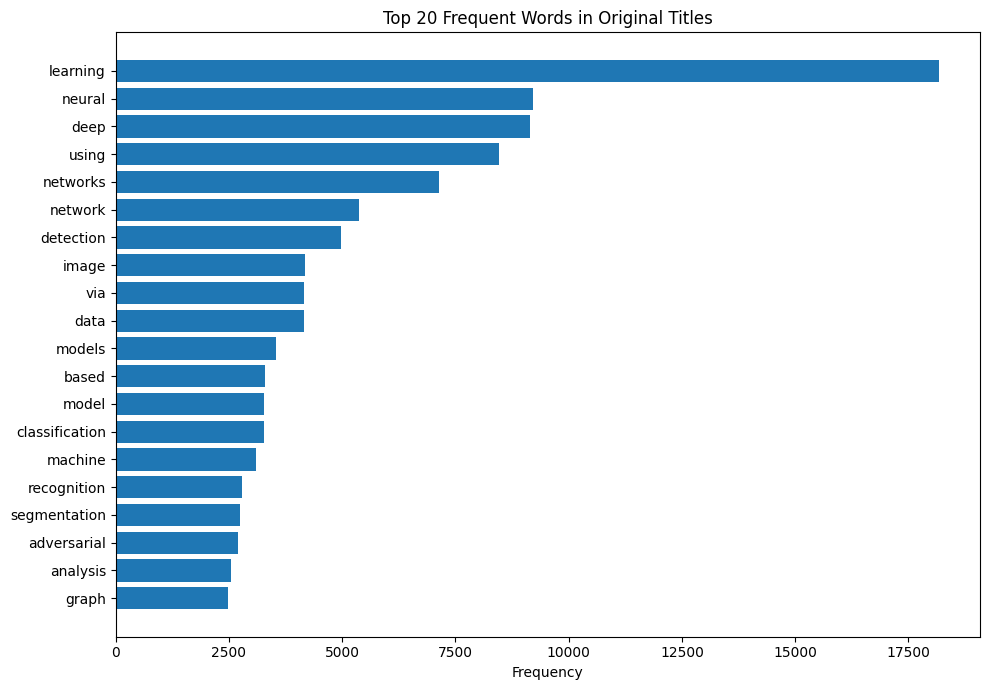

In [ ]:
original_words = []

for title in train_df["original_title"]:
    words = title.lower().split()

    original_words.extend([w for w in words if w not in stop_words])

top20 = Counter(original_words).most_common(20)

words = [x[0] for x in top20]
counts = [x[1] for x in top20]

plt.figure(figsize=(10,7))

plt.barh(words[::-1], counts[::-1])

plt.xlabel("Frequency")
plt.title("Top 20 Frequent Words in Original Titles")

plt.tight_layout()

plt.savefig("/content/drive/MyDrive/FIFI_Research/figures/Figure4_top20_original_words.png",
            dpi=300)

plt.show()

In [ ]:
!pip install wordcloud

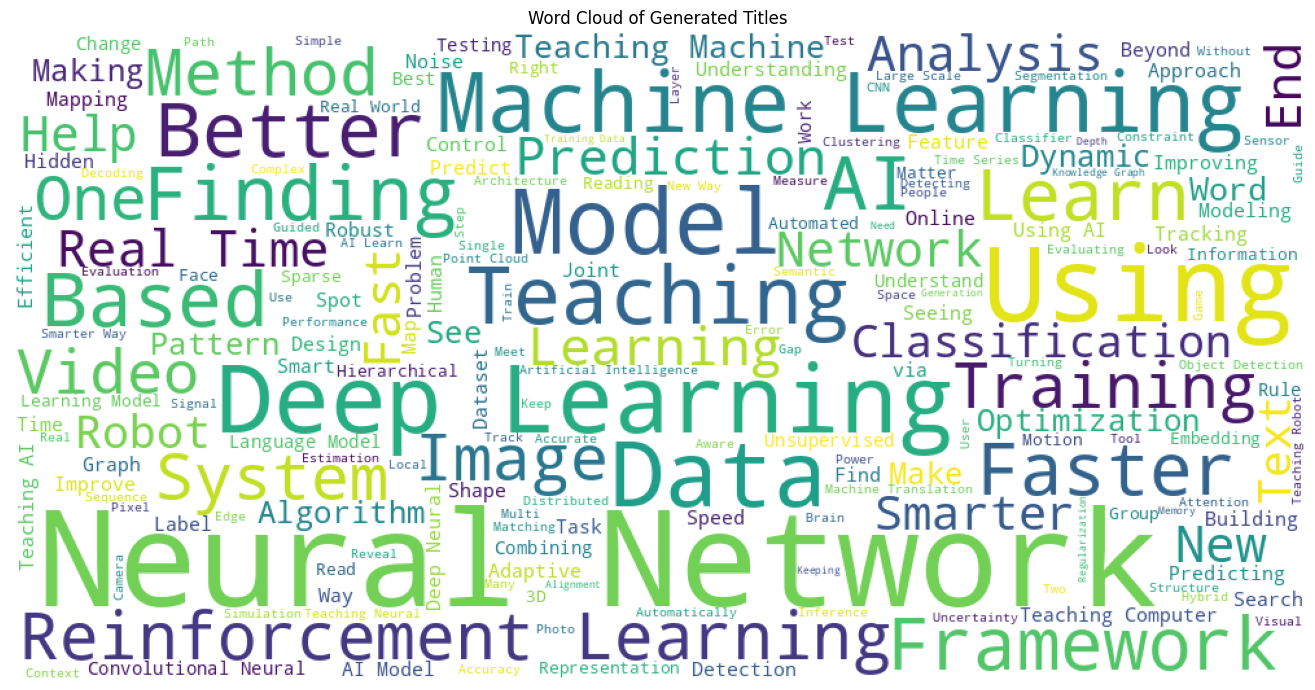

In [ ]:
from wordcloud import WordCloud

generated_text = " ".join(train_df["generated_title"])

wc = WordCloud(width=1000,
               height=500,
               background_color="white").generate(generated_text)

plt.figure(figsize=(15,7))

plt.imshow(wc)

plt.axis("off")

plt.title("Word Cloud of Generated Titles")

plt.tight_layout()

plt.savefig("/content/drive/MyDrive/FIFI_Research/figures/Figure5_generated_wordcloud.png",
            dpi=300)

plt.show()

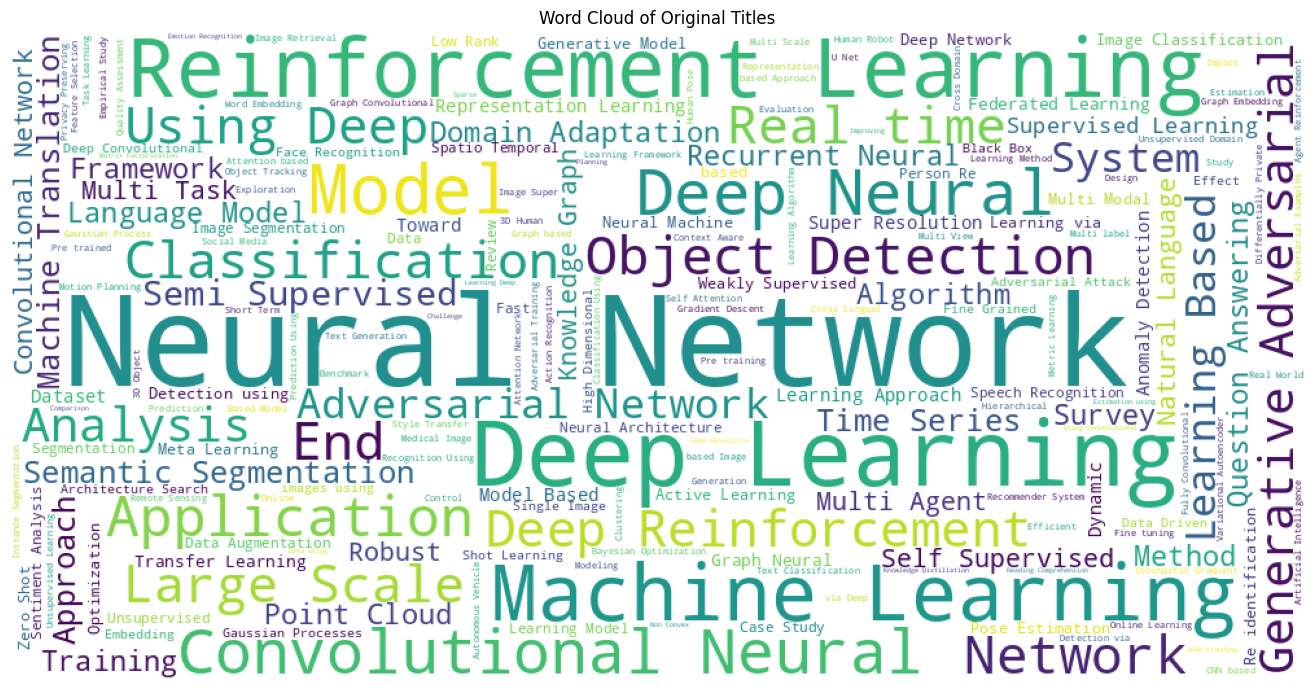

In [ ]:
original_text = " ".join(train_df["original_title"])

wc = WordCloud(width=1000,
               height=500,
               background_color="white").generate(original_text)

plt.figure(figsize=(15,7))

plt.imshow(wc)

plt.axis("off")

plt.title("Word Cloud of Original Titles")

plt.tight_layout()

plt.savefig("/content/drive/MyDrive/FIFI_Research/figures/Figure5_original_wordcloud.png",
            dpi=300)

plt.show()

/tmp/ipykernel_969/3513536909.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


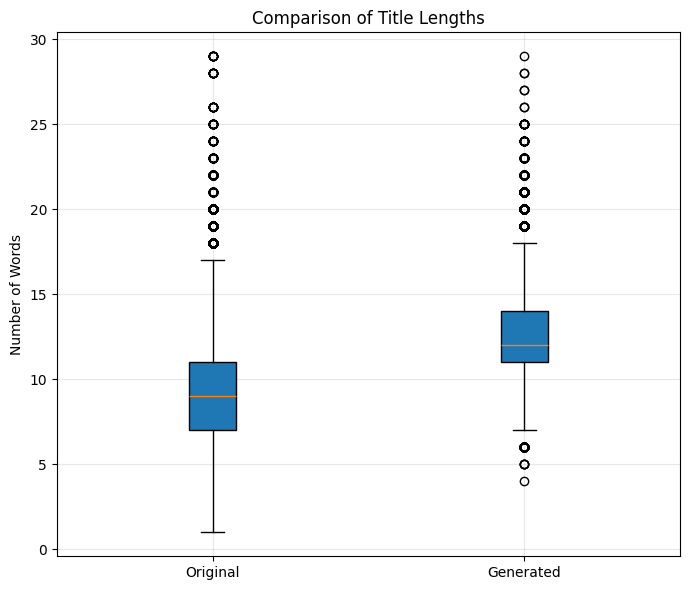

In [ ]:
plot_df = train_df[["generated_words","original_words"]].copy()

plot_df.columns = ["Generated","Original"]

plt.figure(figsize=(7,6))

plt.boxplot(
    [plot_df["Original"], plot_df["Generated"]],
    labels=["Original", "Generated"],
    patch_artist=True
)

plt.ylabel("Number of Words")

plt.title("Comparison of Title Lengths")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("/content/drive/MyDrive/FIFI_Research/figures/Figure6_boxplot.png",
            dpi=300)

plt.show()

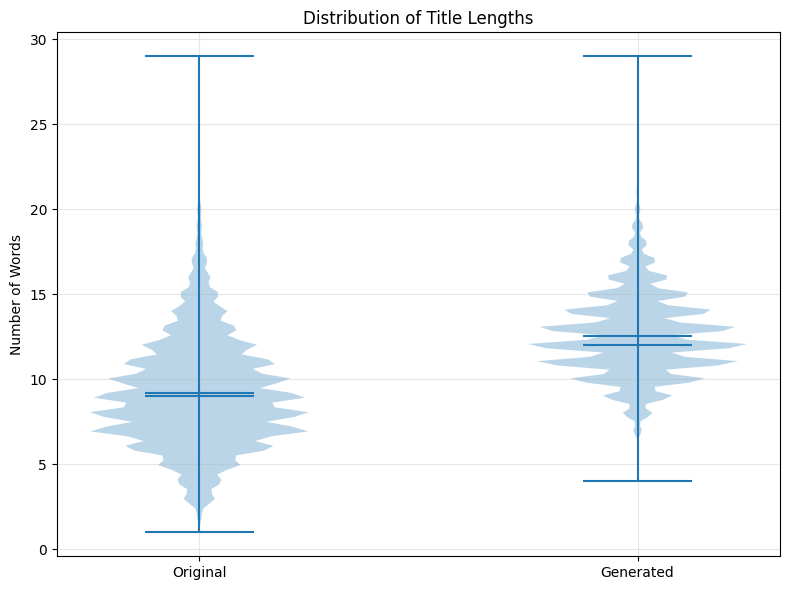

In [ ]:
plot_df = train_df[["generated_words","original_words"]].copy()

plot_df.columns = ["Generated","Original"]

data = [plot_df["Original"], plot_df["Generated"]]

plt.figure(figsize=(8,6))

parts = plt.violinplot(
    data,
    showmeans=True,
    showmedians=True
)

plt.xticks([1,2],["Original","Generated"])

plt.ylabel("Number of Words")

plt.title("Distribution of Title Lengths")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("/content/drive/MyDrive/FIFI_Research/figures/Figure7_violinplot.png",
            dpi=300)

plt.show()

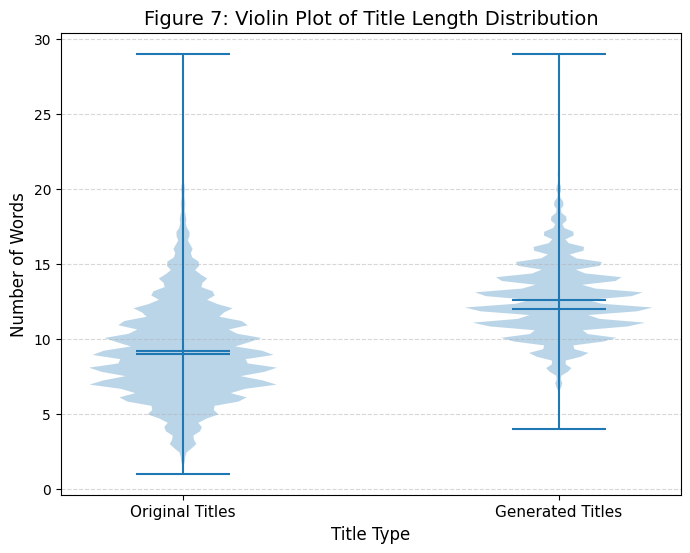

In [ ]:
import matplotlib.pyplot as plt

# Prepare data
original_lengths = train_df["original_words"]
generated_lengths = train_df["generated_words"]

plt.figure(figsize=(8,6))

# Create violin plot
violin = plt.violinplot(
    [original_lengths, generated_lengths],
    showmeans=True,
    showmedians=True,
    showextrema=True
)

# Labels
plt.xticks([1, 2], ["Original Titles", "Generated Titles"], fontsize=11)
plt.ylabel("Number of Words", fontsize=12)
plt.xlabel("Title Type", fontsize=12)
plt.title("Figure 7: Violin Plot of Title Length Distribution", fontsize=14)

# Add grid
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Save figure
plt.savefig(
    "/content/drive/MyDrive/FIFI_Research/figures/Figure7_ViolinPlot_TitleLength.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
### Observation 1

# The dataset contains 90,000 training samples generated from 9,999 unique scientific titles, indicating that each source title has multiple stylistic reformulations.

# This many-to-one relationship makes both retrieval and reconstruction tasks substantially more challenging than conventional text matching.

In [ ]:
### Observation 2

# Generated titles are approximately 37% longer than original titles on average.

# This suggests that LLMs tend to expand descriptions rather than merely replacing terminology.

In [ ]:
### Observation 3

# The balanced distribution across Technical, Accessible, and Catchy categories ensures that the dataset does not introduce style-based class imbalance during model training.